# House Pricing Analysis and Prediction

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('dataset/House Pricing PK/house-pricing.csv')
data.head(10)

,property_id,location_id,page_url,property_type,price,location,city,province_name,latitude,longitude,baths,area,purpose,bedrooms,date_added,agency,agent,Area Type,Area Size,Area Category
0,237062,3325,https://www.zameen.com/Property/g_10_g_10_2_gr...,Flat,10000000,G-10,Islamabad,Islamabad Capital,33.679890,73.012640,2,4 Marla,For Sale,2,02-04-2019,NaN,NaN,Marla,4.0,0-5 Marla
1,346905,3236,https://www.zameen.com/Property/e_11_2_service...,Flat,6900000,E-11,Islamabad,Islamabad Capital,33.700993,72.971492,3,5.6 Marla,For Sale,3,05-04-2019,NaN,NaN,Marla,5.6,5-10 Marla
2,386513,764,https://www.zameen.com/Property/islamabad_g_15...,House,16500000,G-15,Islamabad,Islamabad Capital,33.631486,72.926559,6,8 Marla,For Sale,5,07-17-2019,NaN,NaN,Marla,8.0,5-10 Marla
3,656161,340,https://www.zameen.com/Property/islamabad_bani...,House,43500000,Bani Gala,Islamabad,Islamabad Capital,33.707573,73.151199,4,2 Kanal,For Sale,4,04-05-2019,NaN,NaN,Kanal,2.0,1-5 Kanal
4,841645,3226,https://www.zameen.com/Property/dha_valley_dha...,House,7000000,DHA Defence,Islamabad,Islamabad Capital,33.492591,73.301339,3,8 Marla,For Sale,3,07-10-2019,Easy Property,Muhammad Junaid Ceo Muhammad Shahid Director,Marla,8.0,5-10 Marla
5,850762,3390,https://www.zameen.com/Property/ghauri_town_gh...,House,34500000,Ghauri Town,Islamabad,Islamabad Capital,33.623947,73.126588,8,1.6 Kanal,For Sale,8,04-05-2019,NaN,NaN,Kanal,1.6,1-5 Kanal
6,937975,445,https://www.zameen.com/Property/islamabad_kora...,House,27000000,Korang Town,Islamabad,Islamabad Capital,33.579034,73.139591,8,1 Kanal,For Sale,8,01-04-2019,NaN,NaN,Kanal,1.0,1-5 Kanal
7,1258636,3241,https://www.zameen.com/Property/e_11_e_11_4_ap...,Flat,7800000,E-11,Islamabad,Islamabad Capital,33.698244,72.984238,2,6.2 Marla,For Sale,2,05-05-2019,Ettemad Enterprises,Balqiaz Marwat,Marla,6.2,5-10 Marla
8,1402466,376,https://www.zameen.com/Property/dha_defence_dh...,House,50000000,DHA Defence,Islamabad,Islamabad Capital,33.540894,73.095732,7,1 Kanal,For Sale,7,10-19-2018,Easy Property,Muhammad Junaid Ceo Muhammad Shahid Director,Kanal,1.0,1-5 Kanal
9,1418706,3282,https://www.zameen.com/Property/f_11_f_11_1_f_...,Penthouse,40000000,F-11,Islamabad,Islamabad Capital,33.679211,72.988787,5,1 Kanal,For Sale,5,06-27-2019,Crown Associate,Abrar Ahmed,Kanal,1.0,1-5 Kanal


## Phase 1: Data Inspection
<p>In this phase, we analyze the structure, shape, and types of data present in the dataset.</p>


In [3]:
data.shape

(168446, 20)

In [4]:
data.columns

Index(['property_id', 'location_id', 'page_url', 'property_type', 'price',
       'location', 'city', 'province_name', 'latitude', 'longitude', 'baths',
       'area', 'purpose', 'bedrooms', 'date_added', 'agency', 'agent',
       'Area Type', 'Area Size', 'Area Category'],
      dtype='object')

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168446 entries, 0 to 168445
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   property_id    168446 non-null  int64  
 1   location_id    168446 non-null  int64  
 2   page_url       168446 non-null  object 
 3   property_type  168446 non-null  object 
 4   price          168446 non-null  int64  
 5   location       168446 non-null  object 
 6   city           168446 non-null  object 
 7   province_name  168446 non-null  object 
 8   latitude       168446 non-null  float64
 9   longitude      168446 non-null  float64
 10  baths          168446 non-null  int64  
 11  area           168446 non-null  object 
 12  purpose        168446 non-null  object 
 13  bedrooms       168446 non-null  int64  
 14  date_added     168446 non-null  object 
 15  agency         124375 non-null  object 
 16  agent          124374 non-null  object 
 17  Area Type      168446 non-nul

In [6]:
data.nunique()

property_id      168446
location_id        4198
page_url         168446
property_type         7
price              2077
location           1509
city                  5
province_name         3
latitude           7838
longitude          8316
baths                16
area                344
purpose               2
bedrooms             23
date_added          124
agency             5761
agent             10598
Area Type             2
Area Size           247
Area Category        22
dtype: int64

## Phase 2: Data Cleaning and Preprocessing
<p>Cleaning the data by removing unnecessary columns, handling missing values, and eliminating duplicates.</p>

In [7]:
data.drop(columns=['property_id','page_url','location_id','agency','agent','area','Area Category'], inplace=True)
data.head(10)

,property_type,price,location,city,province_name,latitude,longitude,baths,purpose,bedrooms,date_added,Area Type,Area Size
0,Flat,10000000,G-10,Islamabad,Islamabad Capital,33.679890,73.012640,2,For Sale,2,02-04-2019,Marla,4.0
1,Flat,6900000,E-11,Islamabad,Islamabad Capital,33.700993,72.971492,3,For Sale,3,05-04-2019,Marla,5.6
2,House,16500000,G-15,Islamabad,Islamabad Capital,33.631486,72.926559,6,For Sale,5,07-17-2019,Marla,8.0
3,House,43500000,Bani Gala,Islamabad,Islamabad Capital,33.707573,73.151199,4,For Sale,4,04-05-2019,Kanal,2.0
4,House,7000000,DHA Defence,Islamabad,Islamabad Capital,33.492591,73.301339,3,For Sale,3,07-10-2019,Marla,8.0
5,House,34500000,Ghauri Town,Islamabad,Islamabad Capital,33.623947,73.126588,8,For Sale,8,04-05-2019,Kanal,1.6
6,House,27000000,Korang Town,Islamabad,Islamabad Capital,33.579034,73.139591,8,For Sale,8,01-04-2019,Kanal,1.0
7,Flat,7800000,E-11,Islamabad,Islamabad Capital,33.698244,72.984238,2,For Sale,2,05-05-2019,Marla,6.2
8,House,50000000,DHA Defence,Islamabad,Islamabad Capital,33.540894,73.095732,7,For Sale,7,10-19-2018,Kanal,1.0
9,Penthouse,40000000,F-11,Islamabad,Islamabad Capital,33.679211,72.988787,5,For Sale,5,06-27-2019,Kanal,1.0


In [8]:
data.isnull().sum()

property_type    0
price            0
location         0
city             0
province_name    0
latitude         0
longitude        0
baths            0
purpose          0
bedrooms         0
date_added       0
Area Type        0
Area Size        0
dtype: int64

<Axes: >

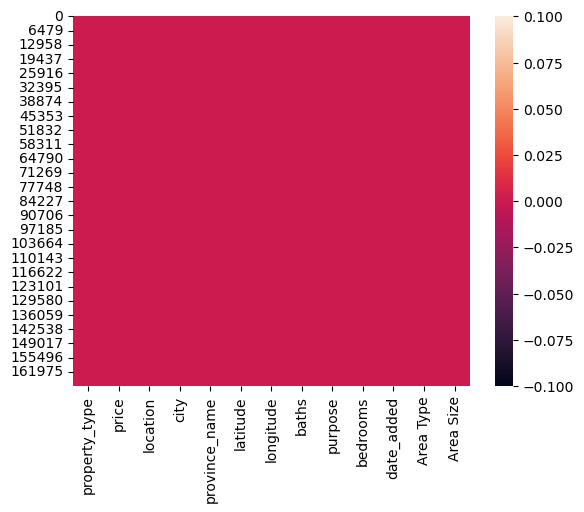

In [9]:
sns.heatmap(data.isnull())

In [10]:
if data.duplicated().sum() > 0:
    print(f'{data.duplicated().sum()} duplicates found')
else:
    print('No duplicate found')

20489 duplicates found


In [11]:
data.drop_duplicates(inplace=True)

In [12]:
if data.duplicated().sum() > 0:
    print(f'{data.duplicated().sum()} duplicates found')
else:
    print('No duplicate found')

No duplicate found


In [13]:
data['Area in sq.ft'] = np.where((data['Area Type'] == 'Marla'), (data['Area Size'] * 225), ((data['Area Size'] * 20 * 225)))
data.head()

,property_type,price,location,city,province_name,latitude,longitude,baths,purpose,bedrooms,date_added,Area Type,Area Size,Area in sq.ft
0,Flat,10000000,G-10,Islamabad,Islamabad Capital,33.679890,73.012640,2,For Sale,2,02-04-2019,Marla,4.0,900.0
1,Flat,6900000,E-11,Islamabad,Islamabad Capital,33.700993,72.971492,3,For Sale,3,05-04-2019,Marla,5.6,1260.0
2,House,16500000,G-15,Islamabad,Islamabad Capital,33.631486,72.926559,6,For Sale,5,07-17-2019,Marla,8.0,1800.0
3,House,43500000,Bani Gala,Islamabad,Islamabad Capital,33.707573,73.151199,4,For Sale,4,04-05-2019,Kanal,2.0,9000.0
4,House,7000000,DHA Defence,Islamabad,Islamabad Capital,33.492591,73.301339,3,For Sale,3,07-10-2019,Marla,8.0,1800.0


In [14]:
data['date_added'] = pd.to_datetime(data['date_added'])
data.head()

,property_type,price,location,city,province_name,latitude,longitude,baths,purpose,bedrooms,date_added,Area Type,Area Size,Area in sq.ft
0,Flat,10000000,G-10,Islamabad,Islamabad Capital,33.679890,73.012640,2,For Sale,2,2019-02-04,Marla,4.0,900.0
1,Flat,6900000,E-11,Islamabad,Islamabad Capital,33.700993,72.971492,3,For Sale,3,2019-05-04,Marla,5.6,1260.0
2,House,16500000,G-15,Islamabad,Islamabad Capital,33.631486,72.926559,6,For Sale,5,2019-07-17,Marla,8.0,1800.0
3,House,43500000,Bani Gala,Islamabad,Islamabad Capital,33.707573,73.151199,4,For Sale,4,2019-04-05,Kanal,2.0,9000.0
4,House,7000000,DHA Defence,Islamabad,Islamabad Capital,33.492591,73.301339,3,For Sale,3,2019-07-10,Marla,8.0,1800.0


In [15]:
data.drop(columns=['Area Size','Area Type'], inplace=True)
data.head()

,property_type,price,location,city,province_name,latitude,longitude,baths,purpose,bedrooms,date_added,Area in sq.ft
0,Flat,10000000,G-10,Islamabad,Islamabad Capital,33.679890,73.012640,2,For Sale,2,2019-02-04,900.0
1,Flat,6900000,E-11,Islamabad,Islamabad Capital,33.700993,72.971492,3,For Sale,3,2019-05-04,1260.0
2,House,16500000,G-15,Islamabad,Islamabad Capital,33.631486,72.926559,6,For Sale,5,2019-07-17,1800.0
3,House,43500000,Bani Gala,Islamabad,Islamabad Capital,33.707573,73.151199,4,For Sale,4,2019-04-05,9000.0
4,House,7000000,DHA Defence,Islamabad,Islamabad Capital,33.492591,73.301339,3,For Sale,3,2019-07-10,1800.0


## Phase 3: Feature Engineering
<p>Creating new features to enhance the predictive power of our models, such as converting area sizes to a standard unit.</p>

In [16]:
data['Price per sqft'] = round(data['price'] / data['Area in sq.ft'])
data.head()

,property_type,price,location,city,province_name,latitude,longitude,baths,purpose,bedrooms,date_added,Area in sq.ft,Price per sqft
0,Flat,10000000,G-10,Islamabad,Islamabad Capital,33.679890,73.012640,2,For Sale,2,2019-02-04,900.0,11111.0
1,Flat,6900000,E-11,Islamabad,Islamabad Capital,33.700993,72.971492,3,For Sale,3,2019-05-04,1260.0,5476.0
2,House,16500000,G-15,Islamabad,Islamabad Capital,33.631486,72.926559,6,For Sale,5,2019-07-17,1800.0,9167.0
3,House,43500000,Bani Gala,Islamabad,Islamabad Capital,33.707573,73.151199,4,For Sale,4,2019-04-05,9000.0,4833.0
4,House,7000000,DHA Defence,Islamabad,Islamabad Capital,33.492591,73.301339,3,For Sale,3,2019-07-10,1800.0,3889.0


In [17]:
data['Total Rooms'] = data['bedrooms'] + data['baths']
data.head()

,property_type,price,location,city,province_name,latitude,longitude,baths,purpose,bedrooms,date_added,Area in sq.ft,Price per sqft,Total Rooms
0,Flat,10000000,G-10,Islamabad,Islamabad Capital,33.679890,73.012640,2,For Sale,2,2019-02-04,900.0,11111.0,4
1,Flat,6900000,E-11,Islamabad,Islamabad Capital,33.700993,72.971492,3,For Sale,3,2019-05-04,1260.0,5476.0,6
2,House,16500000,G-15,Islamabad,Islamabad Capital,33.631486,72.926559,6,For Sale,5,2019-07-17,1800.0,9167.0,11
3,House,43500000,Bani Gala,Islamabad,Islamabad Capital,33.707573,73.151199,4,For Sale,4,2019-04-05,9000.0,4833.0,8
4,House,7000000,DHA Defence,Islamabad,Islamabad Capital,33.492591,73.301339,3,For Sale,3,2019-07-10,1800.0,3889.0,6


In [18]:
data['City Average Price'] = data.groupby('city')['price'].transform('mean').round()
data

,property_type,price,location,city,province_name,latitude,longitude,baths,purpose,bedrooms,date_added,Area in sq.ft,Price per sqft,Total Rooms,City Average Price
0,Flat,10000000,G-10,Islamabad,Islamabad Capital,33.679890,73.012640,2,For Sale,2,2019-02-04,900.0,11111.0,4,14147909.0
1,Flat,6900000,E-11,Islamabad,Islamabad Capital,33.700993,72.971492,3,For Sale,3,2019-05-04,1260.0,5476.0,6,14147909.0
2,House,16500000,G-15,Islamabad,Islamabad Capital,33.631486,72.926559,6,For Sale,5,2019-07-17,1800.0,9167.0,11,14147909.0
3,House,43500000,Bani Gala,Islamabad,Islamabad Capital,33.707573,73.151199,4,For Sale,4,2019-04-05,9000.0,4833.0,8,14147909.0
4,House,7000000,DHA Defence,Islamabad,Islamabad Capital,33.492591,73.301339,3,For Sale,3,2019-07-10,1800.0,3889.0,6,14147909.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
168440,Flat,4800000,Gadap Town,Karachi,Sindh,25.022481,67.129082,0,For Sale,2,2019-07-18,855.0,5614.0,2,20729418.0
168441,House,26500000,Gadap Town,Karachi,Sindh,25.029909,67.137192,0,For Sale,6,2019-07-18,2160.0,12269.0,6,20729418.0
168442,House,12500000,Gadap Town,Karachi,Sindh,25.017951,67.136393,0,For Sale,3,2019-07-18,1800.0,6944.0,3,20729418.0
168443,House,27000000,Gadap Town,Karachi,Sindh,25.015384,67.116330,0,For Sale,6,2019-07-18,2160.0,12500.0,6,20729418.0


<Axes: xlabel='city', ylabel='price'>

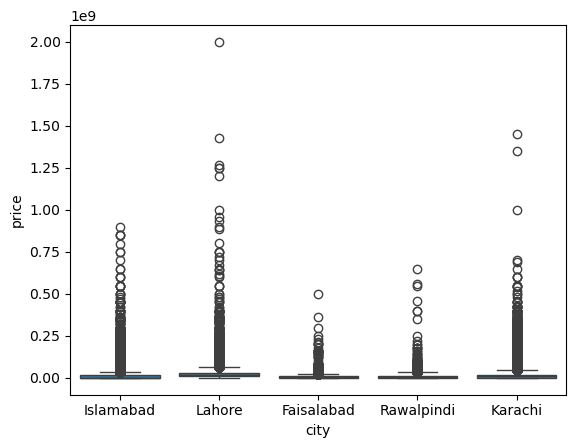

In [19]:
sns.boxplot(data=data, x='city',y='price')

In [20]:
q1, q3 = np.quantile(data['price'], q=[0.25, 0.75])
print(f'q1 {q1}\n q3 {q3}')

IQR = q3 - q1
print(f'IQR {IQR}')

upper_bound = q3 + (1.5 * IQR)
lower_bound = q1 - (1.5 * IQR)
print(f'Lower B {lower_bound}')
print(f'Upper B {upper_bound}')

q1 200000.0
 q3 20000000.0
IQR 19800000.0
Lower B -29500000.0
Upper B 49700000.0


In [21]:
data = data[(data['price'] >= lower_bound) & (data['price'] <= upper_bound)]
data

,property_type,price,location,city,province_name,latitude,longitude,baths,purpose,bedrooms,date_added,Area in sq.ft,Price per sqft,Total Rooms,City Average Price
0,Flat,10000000,G-10,Islamabad,Islamabad Capital,33.679890,73.012640,2,For Sale,2,2019-02-04,900.0,11111.0,4,14147909.0
1,Flat,6900000,E-11,Islamabad,Islamabad Capital,33.700993,72.971492,3,For Sale,3,2019-05-04,1260.0,5476.0,6,14147909.0
2,House,16500000,G-15,Islamabad,Islamabad Capital,33.631486,72.926559,6,For Sale,5,2019-07-17,1800.0,9167.0,11,14147909.0
3,House,43500000,Bani Gala,Islamabad,Islamabad Capital,33.707573,73.151199,4,For Sale,4,2019-04-05,9000.0,4833.0,8,14147909.0
4,House,7000000,DHA Defence,Islamabad,Islamabad Capital,33.492591,73.301339,3,For Sale,3,2019-07-10,1800.0,3889.0,6,14147909.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
168440,Flat,4800000,Gadap Town,Karachi,Sindh,25.022481,67.129082,0,For Sale,2,2019-07-18,855.0,5614.0,2,20729418.0
168441,House,26500000,Gadap Town,Karachi,Sindh,25.029909,67.137192,0,For Sale,6,2019-07-18,2160.0,12269.0,6,20729418.0
168442,House,12500000,Gadap Town,Karachi,Sindh,25.017951,67.136393,0,For Sale,3,2019-07-18,1800.0,6944.0,3,20729418.0
168443,House,27000000,Gadap Town,Karachi,Sindh,25.015384,67.116330,0,For Sale,6,2019-07-18,2160.0,12500.0,6,20729418.0


<Axes: xlabel='city', ylabel='price'>

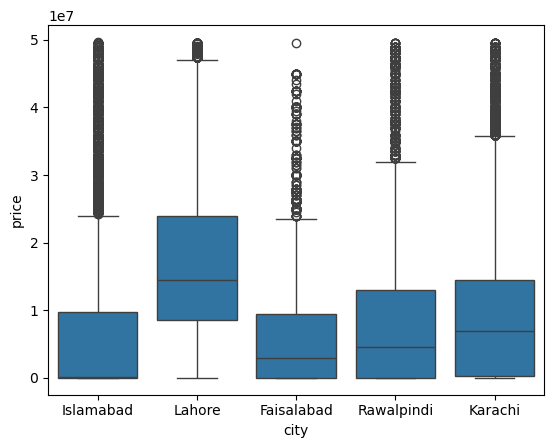

In [22]:
sns.boxplot(data=data, x='city', y='price')

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Flat'),
  Text(1, 0, 'House'),
  Text(2, 0, 'Penthouse'),
  Text(3, 0, 'Lower Portion'),
  Text(4, 0, 'Upper Portion'),
  Text(5, 0, 'Room'),
  Text(6, 0, 'Farm House')])

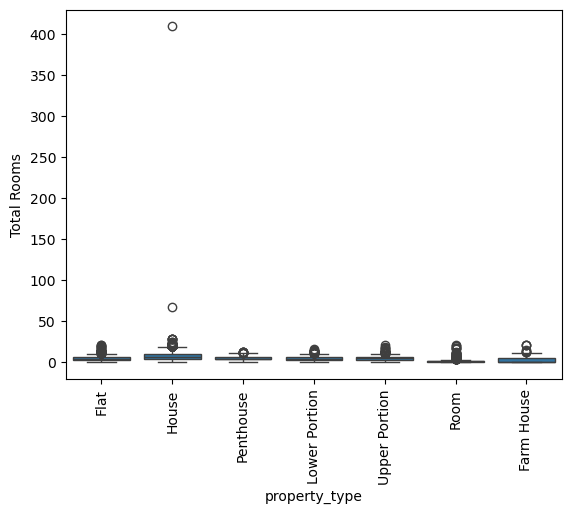

In [23]:
sns.boxplot(data, x='property_type', y='Total Rooms')
plt.xticks(rotation=90)

In [24]:
q1, q3 = np.quantile(data['Total Rooms'], q=[0.25, 0.75])
print(f'q1 {q1}\n q3 {q3}')

IQR = q3 - q1
print(f'IQR {IQR}')

upper_bound = q3 + (1.5 * IQR)
lower_bound = q1 - (1.5 * IQR)
print(f'Lower B {lower_bound}')
print(f'Upper B {upper_bound}')

q1 4.0
 q3 8.0
IQR 4.0
Lower B -2.0
Upper B 14.0


In [25]:
data = data[(data['Total Rooms'] >= lower_bound) & (data['Total Rooms'] <= upper_bound)]

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Flat'),
  Text(1, 0, 'House'),
  Text(2, 0, 'Penthouse'),
  Text(3, 0, 'Lower Portion'),
  Text(4, 0, 'Upper Portion'),
  Text(5, 0, 'Room'),
  Text(6, 0, 'Farm House')])

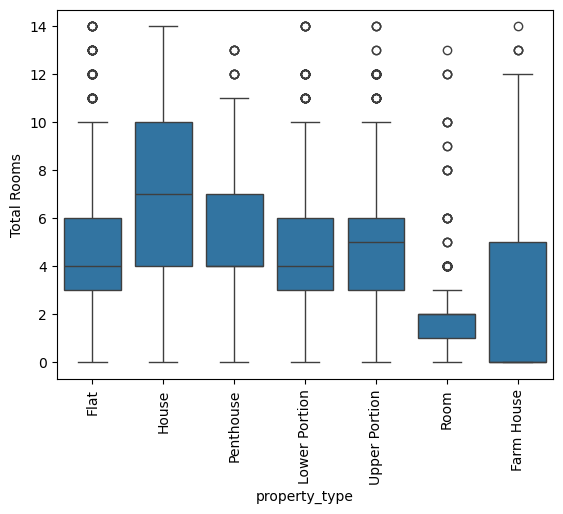

In [26]:
sns.boxplot(data, x='property_type', y='Total Rooms')
plt.xticks(rotation=90)

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Flat'),
  Text(1, 0, 'House'),
  Text(2, 0, 'Penthouse'),
  Text(3, 0, 'Lower Portion'),
  Text(4, 0, 'Upper Portion'),
  Text(5, 0, 'Room'),
  Text(6, 0, 'Farm House')])

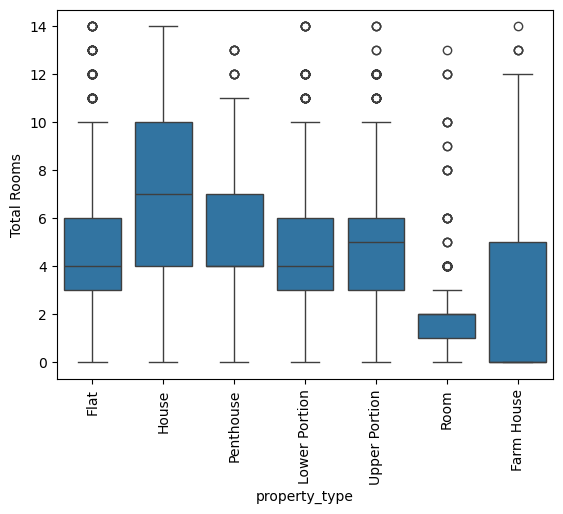

In [27]:
sns.boxplot(data, x='property_type', y='Total Rooms')
plt.xticks(rotation=90)

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Flat'),
  Text(1, 0, 'House'),
  Text(2, 0, 'Penthouse'),
  Text(3, 0, 'Lower Portion'),
  Text(4, 0, 'Upper Portion'),
  Text(5, 0, 'Room'),
  Text(6, 0, 'Farm House')])

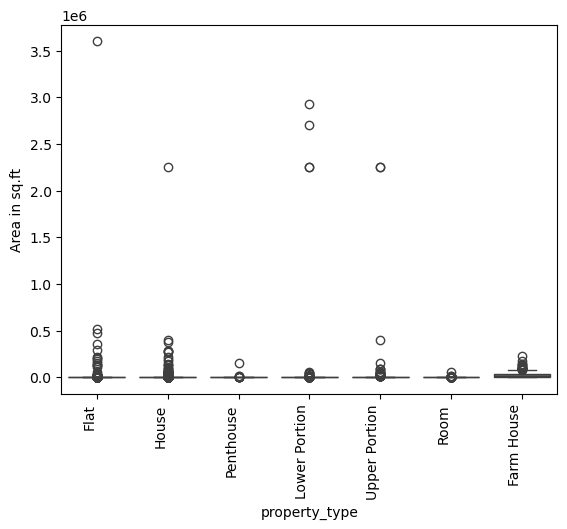

In [28]:
sns.boxplot(data, x='property_type', y='Area in sq.ft')
plt.xticks(rotation=90, ha='right')

In [29]:
q1, q3 = np.quantile(data['Area in sq.ft'], q=[0.25, 0.75])
print(f'q1 {q1}\n q3 {q3}')

IQR = q3 - q1
print(f'IQR {IQR}')

upper_bound = q3 + (1.5 * IQR)
lower_bound = q1 - (1.5 * IQR)
print(f'Lower B {lower_bound}')
print(f'Upper B {upper_bound}')

q1 1080.0
 q3 2250.0
IQR 1170.0
Lower B -675.0
Upper B 4005.0


In [30]:
data = data[(data['Area in sq.ft'] >= lower_bound) & (data['Area in sq.ft'] <= upper_bound)]

Text(0.5, 0, 'Property Type')

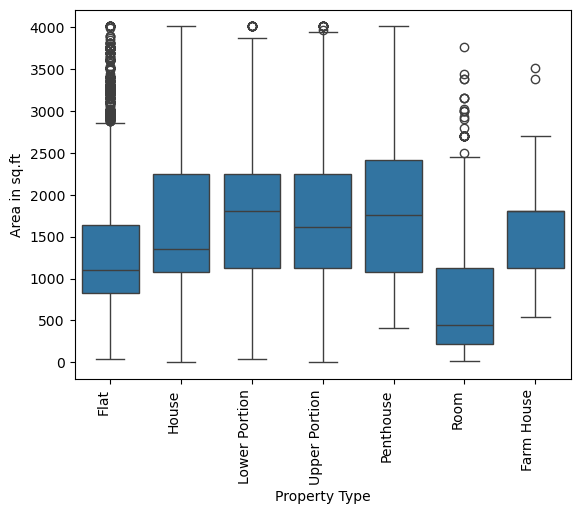

In [31]:
sns.boxplot(data, x='property_type', y='Area in sq.ft')
plt.xticks(rotation=90, ha='right')
plt.xlabel('Property Type')

## Phase 4: Exploratory Data Analysis (EDA) & Visualization
<p>Visualizing the data allows us to identify patterns, city-wise trends, and correlations between property attributes and their market value.</p>

<Axes: xlabel='price', ylabel='Count'>

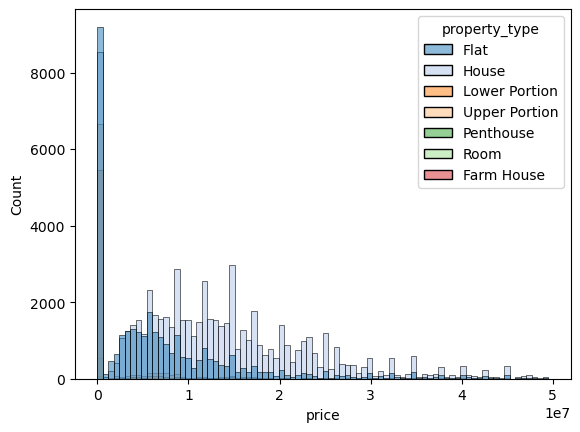

In [32]:
sns.histplot(data=data, x='price', hue='property_type', palette='tab20')

<Axes: >

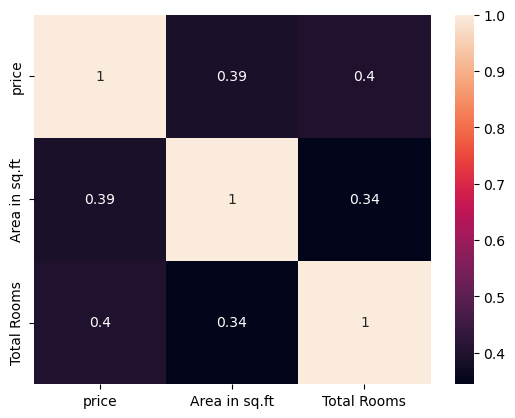

In [33]:
corelation = data[['price', 'Area in sq.ft', 'Total Rooms']].corr()
sns.heatmap(data=corelation, annot=True)

<Axes: xlabel='price', ylabel='Area in sq.ft'>

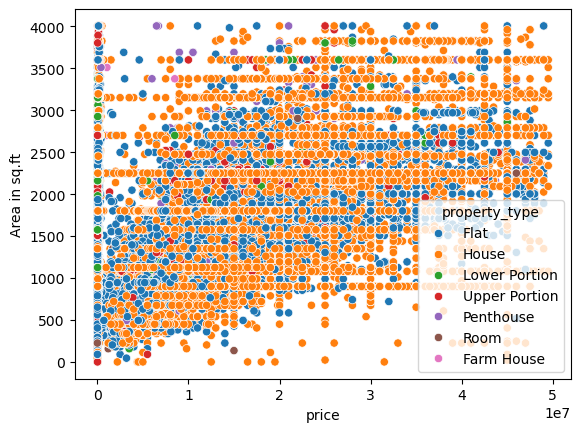

In [34]:
sns.scatterplot(data=data, x='price',y='Area in sq.ft', hue='property_type', palette='tab10')

<Axes: xlabel='Total Rooms', ylabel='price'>

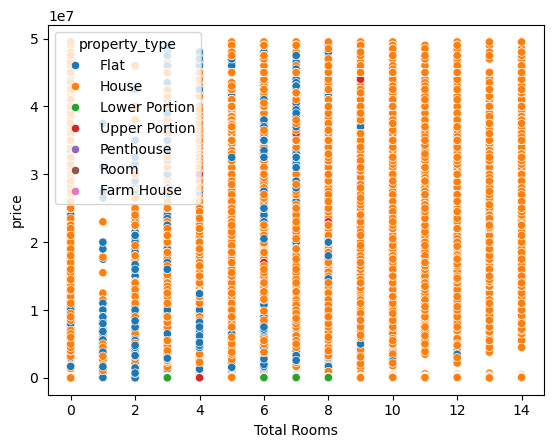

In [35]:
sns.scatterplot(data=data, x='Total Rooms', y='price', hue='property_type')
# plt.plot(data['Total Rooms'] ,data['price'])

<Axes: xlabel='city', ylabel='price'>

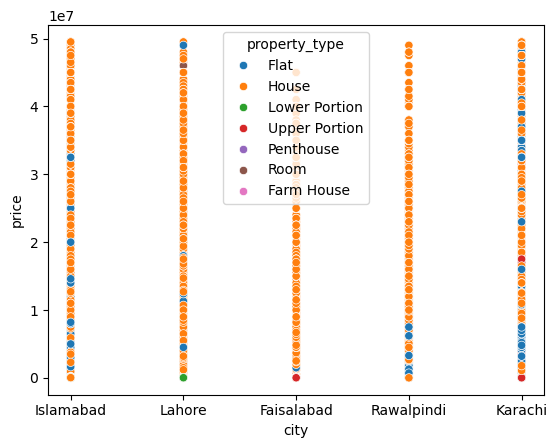

In [36]:
sns.scatterplot(data, x='city',y='price', hue='property_type')

Text(0.5, 0, 'City')

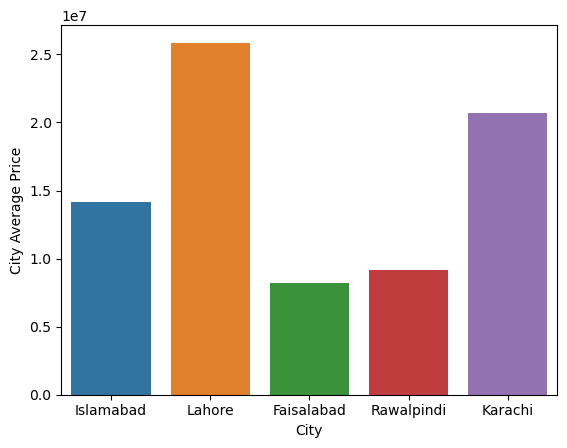

In [37]:
sns.barplot(data,x='city', y='City Average Price',  hue='city')
plt.xlabel('City')

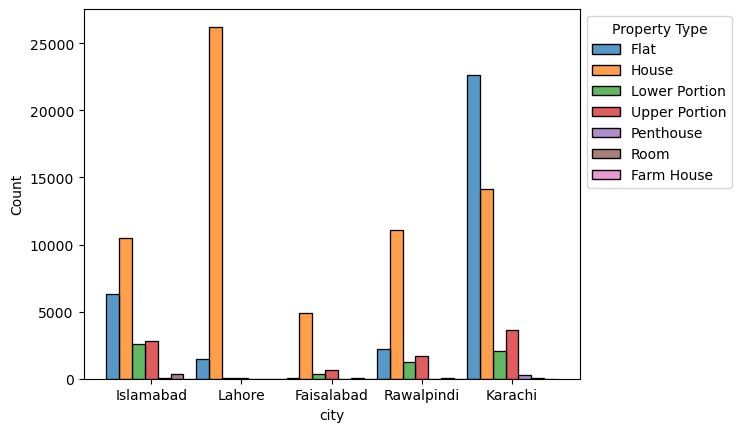

In [38]:
ax = sns.histplot(data=data, x='city', hue='property_type', palette='tab10', multiple='dodge')
sns.move_legend(ax ,title='Property Type', bbox_to_anchor=(1, 1), loc='upper left')

In [39]:
data['Property Type Avg Price'] = data.groupby('property_type')['price'].transform('mean').round()
data.head()

,property_type,price,location,city,province_name,latitude,longitude,baths,purpose,bedrooms,date_added,Area in sq.ft,Price per sqft,Total Rooms,City Average Price,Property Type Avg Price
0,Flat,10000000,G-10,Islamabad,Islamabad Capital,33.679890,73.012640,2,For Sale,2,2019-02-04,900.0,11111.0,4,14147909.0,7580811.0
1,Flat,6900000,E-11,Islamabad,Islamabad Capital,33.700993,72.971492,3,For Sale,3,2019-05-04,1260.0,5476.0,6,14147909.0,7580811.0
2,House,16500000,G-15,Islamabad,Islamabad Capital,33.631486,72.926559,6,For Sale,5,2019-07-17,1800.0,9167.0,11,14147909.0,13053380.0
4,House,7000000,DHA Defence,Islamabad,Islamabad Capital,33.492591,73.301339,3,For Sale,3,2019-07-10,1800.0,3889.0,6,14147909.0,13053380.0
7,Flat,7800000,E-11,Islamabad,Islamabad Capital,33.698244,72.984238,2,For Sale,2,2019-05-05,1395.0,5591.0,4,14147909.0,7580811.0


Text(0, 0.5, 'Avg Price')

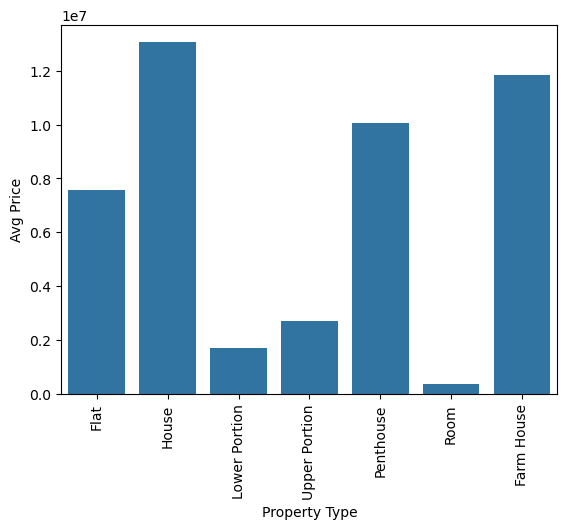

In [40]:
ax = sns.barplot(data, x='property_type', y='Property Type Avg Price')
plt.xticks(rotation=90)
plt.xlabel('Property Type')
plt.ylabel('Avg Price')

In [41]:
data['Avg Price by listing Purpose'] = data.groupby('purpose')['price'].transform('mean').round()
data.head()

,property_type,price,location,city,province_name,latitude,longitude,baths,purpose,bedrooms,date_added,Area in sq.ft,Price per sqft,Total Rooms,City Average Price,Property Type Avg Price,Avg Price by listing Purpose
0,Flat,10000000,G-10,Islamabad,Islamabad Capital,33.679890,73.012640,2,For Sale,2,2019-02-04,900.0,11111.0,4,14147909.0,7580811.0,13567516.0
1,Flat,6900000,E-11,Islamabad,Islamabad Capital,33.700993,72.971492,3,For Sale,3,2019-05-04,1260.0,5476.0,6,14147909.0,7580811.0,13567516.0
2,House,16500000,G-15,Islamabad,Islamabad Capital,33.631486,72.926559,6,For Sale,5,2019-07-17,1800.0,9167.0,11,14147909.0,13053380.0,13567516.0
4,House,7000000,DHA Defence,Islamabad,Islamabad Capital,33.492591,73.301339,3,For Sale,3,2019-07-10,1800.0,3889.0,6,14147909.0,13053380.0,13567516.0
7,Flat,7800000,E-11,Islamabad,Islamabad Capital,33.698244,72.984238,2,For Sale,2,2019-05-05,1395.0,5591.0,4,14147909.0,7580811.0,13567516.0


<Axes: xlabel='purpose', ylabel='Avg Price by listing Purpose'>

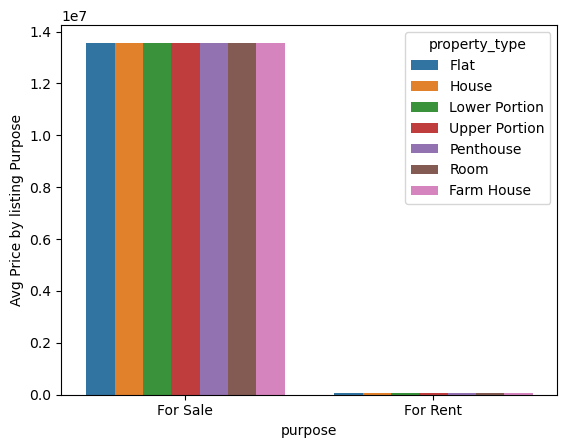

In [42]:
sns.barplot(data, x='purpose', y='Avg Price by listing Purpose', hue='property_type')

## Phase 5 : Key Insights
<p>Based on the data cleaning and exploratory analysis, the following insights were observed:</p>

<h4>1. Which city has highest avg property price?</h4>
<p>&nbsp;&nbsp;&nbsp;&nbsp;Following Grpah show the highest average price of by city</p>
<p>&nbsp;&nbsp;&nbsp;&nbsp;This indicate that Lahore have highest average then all other cities, with averge of Rs.25,854,801</p>
<p>&nbsp;&nbsp;&nbsp;&nbsp;This mean that lahore have most premium housing</p>

Highest Average Price:25854801.0 


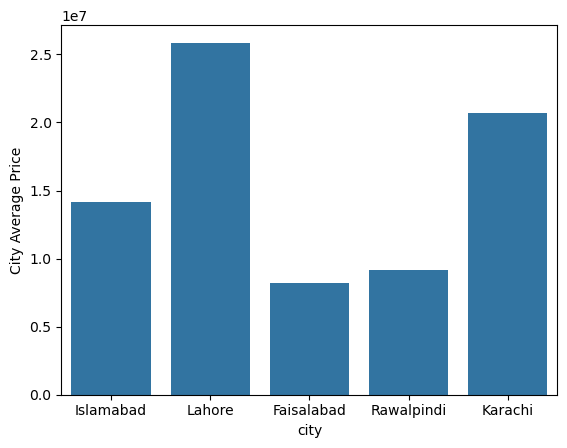

In [43]:
ax = sns.barplot(data=data, x='city',y='City Average Price')
print(f'Highest Average Price:{data['City Average Price'].max()} ')

<h4>1. Does more bedrooms always mean higher price?</h4>
<p>&nbsp;&nbsp;&nbsp;&nbsp;Following Graph illustrate price of house as compare to number of bedroom</p>
<p>&nbsp;&nbsp;&nbsp;&nbsp;This indicate that higher no of bedrooms mean more price, where highest no of bedrooms count is 13 with a price Rs.110,000,00</p>

Highest No of bedroom is 13 with price of 11000000 


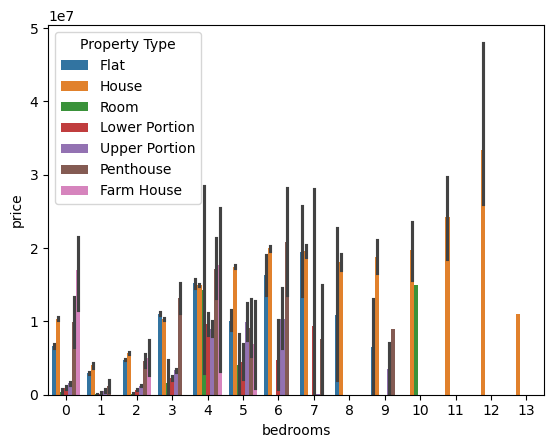

In [44]:
max_no_of_rooms = data['bedrooms'].max()
price_of_highest_no_of_bedroom = data[data['bedrooms'] == max_no_of_rooms]['price'].iloc[0]
print(f'Highest No of bedroom is {max_no_of_rooms} with price of {price_of_highest_no_of_bedroom} ')
sns.barplot(data=data, x='bedrooms', y='price', hue='property_type')
plt.legend(title='Property Type')